# CLUSTERING: Comparison of target RRLs of each UFD with 'labels' obtained with the ML methods

## Libraries

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

from astropy.io import ascii, fits
from astropy.visualization import ZScaleInterval, ImageNormalize
from astropy.io.votable import parse, parse_single_table
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.table import Table, join

from shapely.geometry import Point, Polygon

import csv

import pandas as pd

from scipy.stats import norm, lognorm, expon, gamma

from statistics import mode

import seaborn as sns

from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset


import warnings
warnings.filterwarnings('ignore')

## Data Download

In [2]:
data_booI = pd.read_csv('Output/BootesI/BootesI_rr_final.csv', header=0)
data_booIII = pd.read_csv('Output/BootesIII/BootesIII_rr_final.csv', header=0)
data_carII = pd.read_csv('Output/CarinaII/CarinaII_rr_final.csv', header=0)
data_comber = pd.read_csv('Output/ComaBerenices/ComaBerenices_rr_final.csv', header=0)
data_sgrII = pd.read_csv('Output/SagittariusII/SagittariusII_rr_final.csv', header=0)
data_umaI = pd.read_csv('Output/UrsaMajorI/UrsaMajorI_rr_final.csv', header=0)

data_18mag = pd.read_csv('Data/vari_class_18mag.csv')

dbscan = pd.read_csv('Clustering/output/id_labels_dbscan.csv') ###
hdbscan = pd.read_csv('Clustering/output/id_labels_hdbscan.csv') ###

In [3]:
data_list = [data_booI, data_booIII, data_carII, data_comber, data_sgrII, data_umaI]
ufd_names = ['Bootes I', 'Bootes III', 'Carina II', 'Coma Berenices', 'Sagittarius II', 'Ursa Major I']

In [4]:
data_dbscan = dbscan.merge(data_18mag, on='source_id')
data_hdbscan = hdbscan.merge(data_18mag, on='source_id')

#print(data_dbscan)
#print(data_hdbscan)

## DBSCAN: Comparison of UFDs RRLs

In [5]:
for i in range(0, len(data_list)):
    data = data_list[i]
    ufd = ufd_names[i]
    dataxm = dbscan.merge(data, on = 'source_id')[dbscan.columns]
    
    print('- ' + str(ufd) + ' -')
    print(dataxm)

- Bootes I -
              source_id  label
0   1243152071642576896     -1
1   1230713292302089728   5586
2   1231067163247260160   5910
3   1231507655093621632     -1
4   1230741020611316224   5910
5   1230519198435520128     -1
6   1230612927506112000     -1
7   1230834135502357632     -1
8   1226522469372990208     -1
9   1230833517027065728   5910
10  1230825339409289600     -1
11  1230850009701023232   5910
12  1230827538432572416   5586
13  1230829771815569536   5910
14  1230859630427736832   5910
15  3728687334175665920   6167
16  1230772597210842624   5586
17  1230848326073809280     -1
18  1231064517547444736   5910
19  1230860695583613824   5910
20  1230819704412148224   5910
21  1230836437604328704     -1
22  1230834925776358912   5910
23  1230835853488763008   5910
24  3728695065116355456   5910
- Bootes III -
              source_id  label
0   1242328223900152192   1205
1   1255978763838231680     -1
2   1253064405189570816   1205
3   1248333623267869184     -1
4   1250883

### Boötes I

In [6]:
data_booI_dbscan = data_booI.merge(dbscan, on='source_id')

#print("Target RRLs: " + str(len(data_booI_dbscan)))
#print(data_booI_hdbscan)


## label = 5910

mask5910 = (data_dbscan['label'] == 5910)
data5910 = data_dbscan[mask5910]

print("Sources with label=5910: " + str(len(data5910)))

data_booI_5910 = data_booI_dbscan[data_booI_dbscan['label'] == 5910]
print("BooI RRLs with label=5910: " + str(len(data_booI_5910)))


## label = 5586

mask5586 = (data_dbscan['label'] == 5586)
data5586 = data_dbscan[mask5586]

print("Sources with label=5586: " + str(len(data5586)))

data_booI_5586 = data_booI_dbscan[data_booI_dbscan['label'] == 5586]
print("BooI RRLs with label=5586: " + str(len(data_booI_5586)))


## label = 6167

mask6167 = (data_dbscan['label'] == 6167)
data6167 = data_dbscan[mask6167]

print("Sources with label=6167: " + str(len(data6167)))

data_booI_6167 = data_booI_dbscan[data_booI_dbscan['label'] == 6167]
print("BooI RRLs with label=6167: " + str(len(data_booI_6167)))


## label = -1 (non-clustered)

data_booI_1 = data_booI_dbscan[data_booI_dbscan['label'] == -1]
print("BooI RRLs non-clustered (label=-1): " + str(len(data_booI_1)))

Sources with label=5910: 12
BooI RRLs with label=5910: 12
Sources with label=5586: 3
BooI RRLs with label=5586: 3
Sources with label=6167: 4
BooI RRLs with label=6167: 1
BooI RRLs non-clustered (label=-1): 9


## HDBSCAN

In [7]:
for i in range(0, len(data_list)):
    data = data_list[i]
    ufd = ufd_names[i]
    dataxm = hdbscan.merge(data, on = 'source_id')[hdbscan.columns]
    
    print('- ' + str(ufd) + ' -')
    print(dataxm)

- Bootes I -
              source_id  label
0   1243152071642576896     -1
1   1230713292302089728   5075
2   1231067163247260160   5075
3   1231507655093621632     -1
4   1230741020611316224   5075
5   1230519198435520128     -1
6   1230612927506112000     -1
7   1230834135502357632     -1
8   1226522469372990208     -1
9   1230833517027065728   5075
10  1230825339409289600     -1
11  1230850009701023232   5075
12  1230827538432572416   5075
13  1230829771815569536   5075
14  1230859630427736832   5075
15  3728687334175665920     -1
16  1230772597210842624   5075
17  1230848326073809280     -1
18  1231064517547444736   5075
19  1230860695583613824   5075
20  1230819704412148224   5075
21  1230836437604328704     -1
22  1230834925776358912   5075
23  1230835853488763008   5075
24  3728695065116355456   5075
- Bootes III -
              source_id  label
0   1242328223900152192   2970
1   1255978763838231680     -1
2   1253064405189570816   2970
3   1248333623267869184     -1
4   1250883

### Boötes I

In [8]:
data_booI_hdbscan = data_booI.merge(hdbscan, on='source_id')

#print("Target RRLs: " + str(len(data_booI_hdbscan)))
#print(data_booI_hdbscan)


## label = 5075

mask5075 = (data_hdbscan['label'] == 5075)
data5075 = data_hdbscan[mask5075]

print("Sources with label=5075: " + str(len(data5075)))

data_booI_5075 = data_booI_hdbscan[data_booI_hdbscan['label'] == 5075]
print("BooI RRLs with label=5075: " + str(len(data_booI_5075)))


## label = -1 (non-clustered)

data_booI_1 = data_booI_hdbscan[data_booI_hdbscan['label'] == -1]
print("BooI RRLs non-clustered (label=-1): " + str(len(data_booI_1)))

Sources with label=5075: 20
BooI RRLs with label=5075: 15
BooI RRLs non-clustered (label=-1): 10


#### UFD parameters ([Vivas et al. 2020](https://iopscience.iop.org/article/10.3847/1538-4365/ab67c0), table 1)

In [9]:
vivas_table = pd.read_csv('Papers_tables/Vivas_table1.csv', header=0)

vivas = vivas_table[vivas_table['galaxy'] == 'BootesI']

center = np.array(object=(float(vivas['ra']), float(vivas['dec'])))

r_half = np.array(object=(float(vivas['r_h'])/60.0)) # 10.50 arcmin

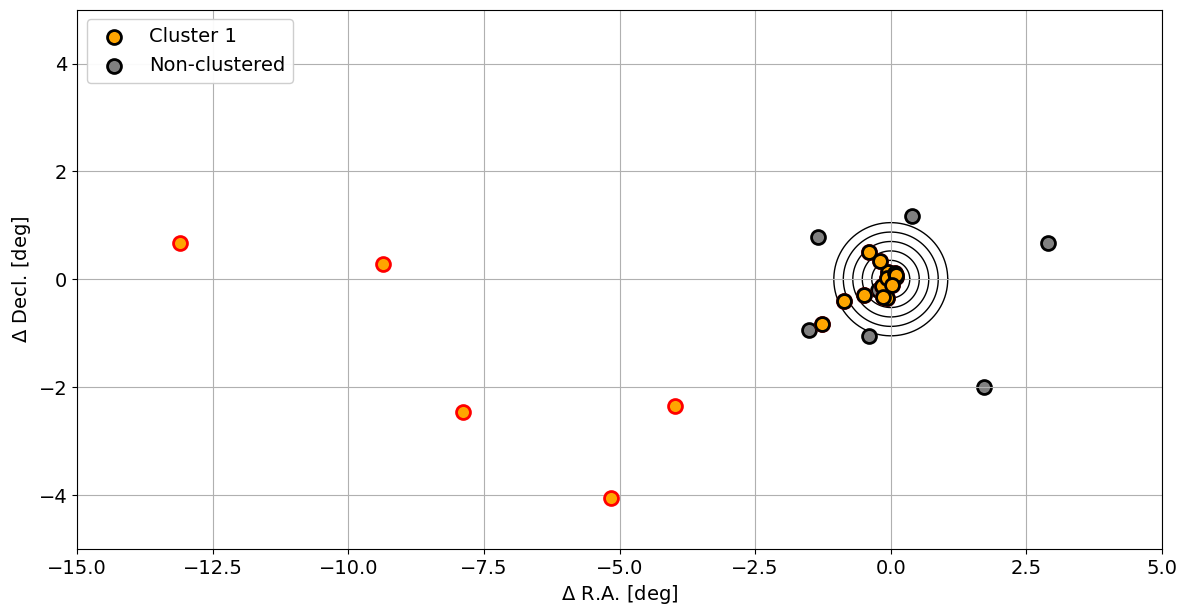

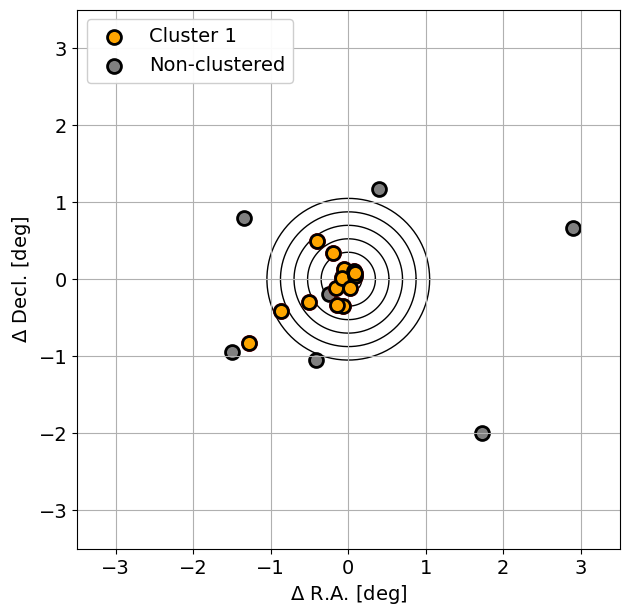

In [10]:
## MAPS

t = np.linspace(0, 2*np.pi, 100)

plt.figure(figsize=(14,7))
plt.xlim(-15,5)
plt.ylim(-5,5)


plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.xlabel(r'$\Delta$ R.A. [deg]', fontsize=14)
plt.ylabel(r'$\Delta$ Decl. [deg]', fontsize=14)

plt.scatter(data_booI_5075['ra'] - center[0], data_booI_5075['dec'] - center[1], s=100, marker='o', c='orange', edgecolor='k', linewidth=2, label='Cluster 1', zorder=3)
plt.scatter(data5075['ra'] - center[0], data5075['dec'] - center[1], s=100, marker='o', c='orange', edgecolor='red', linewidth=2, zorder=2)#, label='Cluster 1', zorder=2)
plt.scatter(data_booI_1['ra'] - center[0], data_booI_1['dec'] - center[1], s=100, marker='o', c='grey', edgecolor='k', linewidth=2, label='Non-clustered', zorder=1)# (label=-1)', zorder=0)

plt.plot(r_half*1*np.cos(t),r_half*1*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*2*np.cos(t),r_half*2*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*3*np.cos(t),r_half*3*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*4*np.cos(t),r_half*4*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*5*np.cos(t),r_half*5*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*6*np.cos(t),r_half*6*np.sin(t),c='k', linewidth=1, zorder=0)


plt.legend(loc=2, fontsize=14, framealpha=0.95)
plt.grid(True)

plt.savefig('Plot/BootesI/BooI_HDBSCAN_paper10.png', bbox_inches='tight', pad_inches=0.1)

plt.show()



### Zoom-in

plt.figure(figsize=(7,7))
plt.xlim(-3.5,3.5)
plt.ylim(-3.5,3.5)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.xlabel(r'$\Delta$ R.A. [deg]', fontsize=14)
plt.ylabel(r'$\Delta$ Decl. [deg]', fontsize=14)

plt.scatter(data_booI_5075['ra'] - center[0], data_booI_5075['dec'] - center[1], s=100, marker='o', c='orange', edgecolor='k', linewidth=2, label='Cluster 1', zorder=3)
plt.scatter(data5075['ra'] - center[0], data5075['dec'] - center[1], s=100, marker='o', c='orange', edgecolor='red', linewidth=2, zorder=2)#, label='Cluster 1', zorder=2)
plt.scatter(data_booI_1['ra'] - center[0], data_booI_1['dec'] - center[1], s=100, marker='o', c='grey', edgecolor='k', linewidth=2, label='Non-clustered', zorder=1)# (label=-1)', zorder=0)

plt.plot(r_half*1*np.cos(t),r_half*1*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*2*np.cos(t),r_half*2*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*3*np.cos(t),r_half*3*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*4*np.cos(t),r_half*4*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*5*np.cos(t),r_half*5*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*6*np.cos(t),r_half*6*np.sin(t),c='k', linewidth=1, zorder=0)


plt.legend(loc=2, fontsize=14, framealpha=0.95)
plt.grid(True)

plt.savefig('Plot/BootesI/BooI_HDBSCAN_map2.png', bbox_inches='tight', pad_inches=0.1)

plt.show()

### Ursa Major I

In [11]:
data_umaI_hdbscan = data_umaI.merge(hdbscan, on='source_id')

#print("Target RRLs: " + str(len(data_umaI_hdbscan)))
#print(data_umaI_hdbscan)


## label = 512

mask512 = (data_hdbscan['label'] == 512)
data512 = data_hdbscan[mask512]

print("Sources with label=512: " + str(len(data512)))


data_umaI_512 = data_umaI_hdbscan[data_umaI_hdbscan['label'] == 512]
print("UMaI RRLs with label=512: " + str(len(data_umaI_512)))


## label = -1 (non-clustered)

data_umaI_1 = data_umaI_hdbscan[data_umaI_hdbscan['label'] == -1]
print("UMaI RRLs non-clustered (label=-1): " + str(len(data_umaI_1)))

Sources with label=512: 9
UMaI RRLs with label=512: 7
UMaI RRLs non-clustered (label=-1): 1


#### UFD parameters ([Vivas et al. 2020](https://iopscience.iop.org/article/10.3847/1538-4365/ab67c0), table 1)

In [12]:
vivas_table = pd.read_csv('Papers_tables/Vivas_table1.csv', header=0)

vivas = vivas_table[vivas_table['galaxy'] == 'UrsaMajorI']

center = np.array(object=(float(vivas['ra']), float(vivas['dec'])))

r_half = np.array(object=(float(vivas['r_h'])/60.0)) # 8.13 arcmin

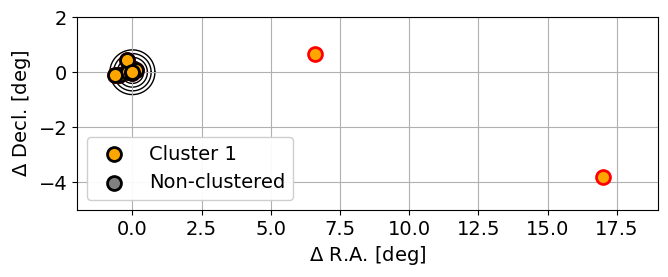

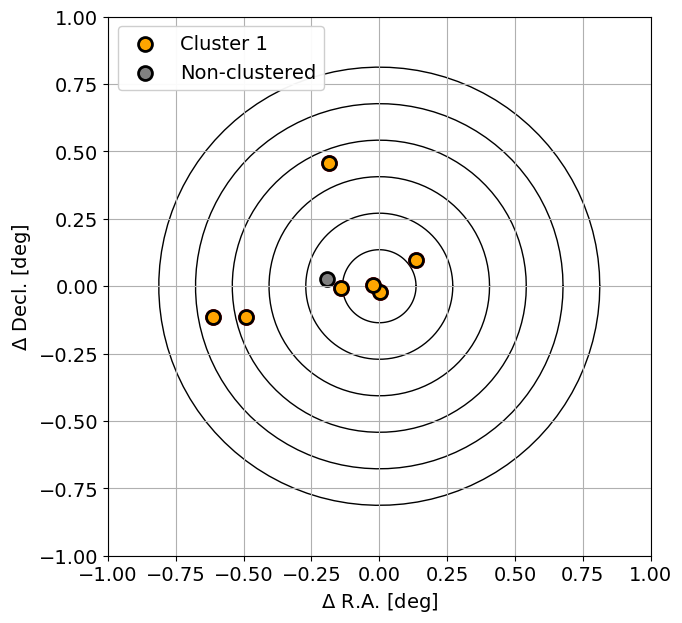

In [13]:
## MAPS

t = np.linspace(0, 2*np.pi, 100)

plt.figure(figsize=(7.5,2.5))
plt.xlim(-2,19)
plt.ylim(-5,2)


plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.xlabel(r'$\Delta$ R.A. [deg]', fontsize=14)
plt.ylabel(r'$\Delta$ Decl. [deg]', fontsize=14)

plt.scatter(data_umaI_512['ra'] - center[0], data_umaI_512['dec'] - center[1], s=100, marker='o', c='orange', edgecolor='k', linewidth=2, label='Cluster 1', zorder=3)
plt.scatter(data512['ra'] - center[0], data512['dec'] - center[1], s=100, marker='o', c='orange', edgecolor='red', linewidth=2, zorder=2)#, label='Cluster 1', zorder=2)
plt.scatter(data_umaI_1['ra'] - center[0], data_umaI_1['dec'] - center[1], s=100, marker='o', c='grey', edgecolor='k', linewidth=2, label='Non-clustered', zorder=1)# (label=-1)', zorder=0)

plt.plot(r_half*1*np.cos(t),r_half*1*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*2*np.cos(t),r_half*2*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*3*np.cos(t),r_half*3*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*4*np.cos(t),r_half*4*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*5*np.cos(t),r_half*5*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*6*np.cos(t),r_half*6*np.sin(t),c='k', linewidth=1, zorder=0)


plt.legend(loc=3, fontsize=14, framealpha=0.95)
plt.grid(True)

plt.savefig('Plot/UrsaMajorI/UMaI_HDBSCAN_map1.png', bbox_inches='tight', pad_inches=0.1)

plt.show()



### Zoom-in

plt.figure(figsize=(7,7))
plt.xlim(-1,1)
plt.ylim(-1,1)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.xlabel(r'$\Delta$ R.A. [deg]', fontsize=14)
plt.ylabel(r'$\Delta$ Decl. [deg]', fontsize=14)

plt.scatter(data_umaI_512['ra'] - center[0], data_umaI_512['dec'] - center[1], s=100, marker='o', c='orange', edgecolor='k', linewidth=2, label='Cluster 1', zorder=3)
plt.scatter(data512['ra'] - center[0], data512['dec'] - center[1], s=100, marker='o', c='orange', edgecolor='red', linewidth=2, zorder=2)#, label='Cluster 1', zorder=2)
plt.scatter(data_umaI_1['ra'] - center[0], data_umaI_1['dec'] - center[1], s=100, marker='o', c='grey', edgecolor='k', linewidth=2, label='Non-clustered', zorder=1)# (label=-1)', zorder=0)

plt.plot(r_half*1*np.cos(t),r_half*1*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*2*np.cos(t),r_half*2*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*3*np.cos(t),r_half*3*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*4*np.cos(t),r_half*4*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*5*np.cos(t),r_half*5*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*6*np.cos(t),r_half*6*np.sin(t),c='k', linewidth=1, zorder=0)


plt.legend(loc=2, fontsize=14, framealpha=0.95)
plt.grid(True)

plt.savefig('Plot/UrsaMajorI/UMaI_HDBSCAN_map2.png', bbox_inches='tight', pad_inches=0.1)

plt.show()